In [39]:
import os
os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

In [40]:
# install rpy2 if needed:
# pip install rpy2

In [41]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [42]:
%%R
install.packages(c("tidyverse", "rvest", "remotes"), repos = "https://cran.r-project.org")
remotes::install_github("hrbrmstr/waffle")


The downloaded binary packages are in
	/var/folders/j5/twx6v7jj4nq17ymrbt5c1klw0000gn/T//RtmpjXthkN/downloaded_packages


trying URL 'https://cran.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/tidyverse_2.0.0.tgz'
trying URL 'https://cran.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/rvest_1.0.5.tgz'
trying URL 'https://cran.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/remotes_2.5.0.tgz'
Skipping install of 'waffle' from a github remote, the SHA1 (767875bf) has not changed since last install.
  Use `force = TRUE` to force installation


In [43]:
%%R
library(tidyverse)
library(rvest)
library(waffle)

In [44]:
%%R
PATH <- "/Users/haiyib/table-tennis-rankings/table-tennis"
cat("=== CSVs ===\n")
print(list.files(PATH, pattern = "\\.csv$", ignore.case = TRUE))
cat("\n=== HTMLs ===\n")
print(list.files(PATH, pattern = "\\.html$", ignore.case = TRUE))

=== CSVs ===
[1] "ittf_doubles_top10.csv"  "ittf_top5_2005_2025.csv"

=== HTMLs ===
[1] "index.html"


In [45]:
%%R
read_csv_file <- function(filepath, category, yr) {
  read_csv(filepath, show_col_types = FALSE) |>
    mutate(
      category = category,
      year     = as.integer(yr),
      rank     = as.integer(Rank),
      country  = str_trim(Assoc),
      pair     = str_trim(Name)
    ) |>
    filter(rank <= 10) |>
    select(category, year, rank, country, pair)
}

csv_data <- bind_rows(
  map_dfr(2017:2020, function(y) {
    for (w in c(12, 49, 52, 53, 51, 50)) {
      f <- file.path(PATH, "ranking-csv", sprintf("Men Doubles_Y%d_w%d.csv", y, w))
      if (file.exists(f)) { message("Found: ", basename(f)); return(read_csv_file(f, "Men\'s doubles", y)) }
    }
    message("Missing men CSV for ", y); return(NULL)
  }),
  map_dfr(2017:2020, function(y) {
    for (w in c(12, 49, 52, 53, 51, 50)) {
      f <- file.path(PATH, "ranking-csv", sprintf("Women Doubles_Y%d_w%d.csv", y, w))
      if (file.exists(f)) { message("Found: ", basename(f)); return(read_csv_file(f, "Women\'s doubles", y)) }
    }
    message("Missing women CSV for ", y); return(NULL)
  })
)

print(csv_data)

# A tibble: 80 × 5
   category       year  rank country pair                            
   <chr>         <int> <int> <chr>   <chr>                           
 1 Men's doubles  2017     1 JPN     MORIZONO Masataka/OSHIMA Yuya   
 2 Men's doubles  2017     2 MIX     FRANZISKA Patrick/GROTH Jonathan
 3 Men's doubles  2017     3 CHN     FAN Zhendong/XU Xin             
 4 Men's doubles  2017     4 JPN     NIWA Koki/YOSHIMURA Maharu      
 5 Men's doubles  2017     5 JPN     UEDA Jin/YOSHIMURA Maharu       
 6 Men's doubles  2017     6 KOR     JEOUNG Youngsik/LEE Sangsu      
 7 Men's doubles  2017     7 BRA     CALDERANO Hugo/TSUBOI Gustavo   
 8 Men's doubles  2017     8 GER     FILUS Ruwen/WALTHER Ricardo     
 9 Men's doubles  2017     9 BEL     DEVOS Robin/NUYTINCK Cedric     
10 Men's doubles  2017    10 HKG     HO Kwan Kit/WONG Chun Ting      
# ℹ 70 more rows
# ℹ Use `print(n = ...)` to see more rows


Found: Men Doubles_Y2017_w12.csv
Found: Men Doubles_Y2018_w12.csv
Found: Men Doubles_Y2019_w49.csv
Found: Men Doubles_Y2020_w49.csv
Found: Women Doubles_Y2017_w12.csv
Found: Women Doubles_Y2018_w12.csv
Found: Women Doubles_Y2019_w49.csv
Found: Women Doubles_Y2020_w49.csv


In [46]:
%%R
read_html_file <- function(filepath, year, category) {
  page   <- read_html(filepath)
  tables <- page |> html_table(fill = TRUE)
  tbl    <- tables[[which(map_int(tables, ncol) >= 4)[1]]]
  tbl    <- tbl[, 1:4]
  names(tbl) <- c("rank_raw", "pair", "country", "points")
  tbl |>
    mutate(rank = suppressWarnings(as.integer(rank_raw))) |>
    filter(!is.na(rank), rank <= 10) |>
    mutate(category = category, year = as.integer(year)) |>
    select(category, year, rank, country, pair)
}

html_data <- bind_rows(
  map_dfr(2021:2025, function(y) {
    for (w in c(52, 53, 51)) {
      f <- file.path(PATH, "webpage-ittf", sprintf("%d_%02d_SEN_MD.html", y, w))
      if (file.exists(f)) { message("Found: ", basename(f)); return(read_html_file(f, y, "Men\'s doubles")) }
    }
    message("Missing men HTML for ", y); return(NULL)
  }),
  map_dfr(2021:2025, function(y) {
    for (w in c(52, 53, 51)) {
      f <- file.path(PATH, "webpage-ittf", sprintf("%d_%02d_SEN_WD.html", y, w))
      if (file.exists(f)) { message("Found: ", basename(f)); return(read_html_file(f, y, "Women\'s doubles")) }
    }
    message("Missing women HTML for ", y); return(NULL)
  })
)

print(html_data)

# A tibble: 100 × 5
   category       year  rank country   pair                             
   <chr>         <int> <int> <chr>     <chr>                            
 1 Men's doubles  2021     1 SWE       Kristian KARLSSON / Mattias FALCK
 2 Men's doubles  2021     2 KOR       JANG Woojin / LIM Jonghoon       
 3 Men's doubles  2021     3 JPN       Yukiya UDA / Shunsuke TOGAMI     
 4 Men's doubles  2021     4 CHN       LIN Gaoyuan / LIANG Jingkun      
 5 Men's doubles  2021     5 KOR       JEOUNG Youngsik / LEE Sangsu     
 6 Men's doubles  2021     6 ARG       Gaston ALTO / Horacio CIFUENTES  
 7 Men's doubles  2021     7 GER       Dang QIU / Benedikt DUDA         
 8 Men's doubles  2021     8 ROU / ESP Ovidiu IONESCU / Alvaro ROBLES   
 9 Men's doubles  2021     9 HUN       Nandor ECSEKI / Adam SZUDI       
10 Men's doubles  2021    10 TPE       CHEN Chien-An / CHUANG Chih-Yuan 
# ℹ 90 more rows
# ℹ Use `print(n = ...)` to see more rows


Found: 2021_52_SEN_MD.html
Found: 2022_52_SEN_MD.html
Found: 2023_52_SEN_MD.html
Found: 2024_52_SEN_MD.html
Found: 2025_52_SEN_MD.html
Found: 2021_52_SEN_WD.html
Found: 2022_52_SEN_WD.html
Found: 2023_52_SEN_WD.html
Found: 2024_52_SEN_WD.html
Found: 2025_52_SEN_WD.html


In [47]:
%%R
df <- bind_rows(csv_data, html_data) |>
  mutate(
    nation = case_when(
      country == "CHN" ~ "China",
      country == "JPN" ~ "Japan",
      country == "KOR" ~ "Korea",
      country == "HKG" ~ "Hong Kong",
      country == "FRA" ~ "France",
      country == "TPE" ~ "Chinese Taipei",
      TRUE             ~ "Other"
    ),
    nation = factor(nation, levels = c(
      "Other", "Chinese Taipei", "France", "Hong Kong",
      "Korea", "Japan", "China"
    ))
  )

df |> count(category, year) |> print()

# A tibble: 18 × 3
   category         year     n
   <chr>           <int> <int>
 1 Men's doubles    2017    10
 2 Men's doubles    2018    10
 3 Men's doubles    2019    10
 4 Men's doubles    2020    10
 5 Men's doubles    2021    10
 6 Men's doubles    2022    10
 7 Men's doubles    2023    10
 8 Men's doubles    2024    10
 9 Men's doubles    2025    10
10 Women's doubles  2017    10
11 Women's doubles  2018    10
12 Women's doubles  2019    10
13 Women's doubles  2020    10
14 Women's doubles  2021    10
15 Women's doubles  2022    10
16 Women's doubles  2023    10
17 Women's doubles  2024    10
18 Women's doubles  2025    10


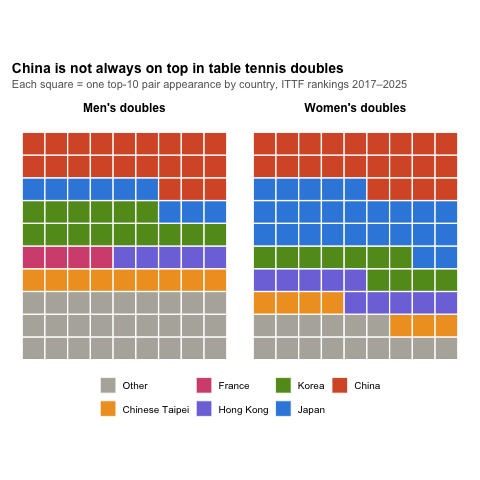

In [51]:
%%R
# Increase inline plot resolution
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

# Aggregate across all years — each square = one top-10 pair appearance
waffle_df <- df |>
  count(category, nation)

nation_colors <- c(
  "China"          = "#D85A30",
  "Japan"          = "#378ADD",
  "Korea"          = "#639922",
  "Hong Kong"      = "#7F77DD",
  "France"         = "#D4537E",
  "Chinese Taipei" = "#EF9F27",
  "Other"          = "#B4B2A9"
)

ggplot(waffle_df, aes(fill = nation, values = n)) +
  geom_waffle(
    n_rows = 9,
    size   = 0.6,
    colour = "white",
    flip   = TRUE
  ) +
  facet_wrap(~category, ncol = 2) +
  scale_fill_manual(values = nation_colors, name = NULL) +
  coord_equal() +
  theme_void(base_size = 12) +
  theme(
    strip.text      = element_text(size = 12, face = "bold", margin = margin(b = 8)),
    legend.position = "bottom",
    legend.text     = element_text(size = 10),
    plot.margin     = margin(12, 12, 12, 12),
    plot.title      = element_text(size = 14, face = "bold", margin = margin(b = 4)),
    plot.subtitle   = element_text(size = 11, color = "grey40", margin = margin(b = 12))
  ) +
  labs(
    title    = "China is not always on top in table tennis doubles",
    subtitle = "Each square = one top-10 pair appearance by country, ITTF rankings 2017–2025"
  )

In [52]:
%%R
ggsave("doubles_waffle.pdf", width = 10, height = 5)
message("Saved to doubles_waffle.pdf")

Saved to doubles_waffle.pdf
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Each square = one top-10 pair appearance by country, ITTF rankings 2017–2025' in 'mbcsToSbcs': - substituted for – (U+2013)
